In [2]:
#ultra needed package

!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.0 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=5cda80a5aee36eb8284c7d3e9c84c7a84f6de2853b258ba04e10c5306159e2fb
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


We will test 3 approaches for this implementation:

* Sequential hill climbing on CPU
* Multi-start hill climbing on GPU using CUDA and GPS
* Generalized pattern search (GPS) on CPU

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule

## Objective Functions

Three one-dimensional functions:

1. `f(x) = x^2`
2. `f(x) = x^4 - 4x^2 + x`
3. `f(x) = x^5 - 10x^3 + 15x`

For the contour plots, I used the separable two-dimensional form:

`F(x, y) = f(x) + f(y)`

This keeps the same behavior of the original functions while allowing the trajectory to be plotted in a 2D plane. The starting point is `x0 = (-6, -6)`.


In [4]:
def f_scalar(x, function_id):
  if function_id==0:
    return x**2
  if function_id==1:
    return x**4-4*x**2+x
  if function_id==2:
    return x**5-10*x**3+15*x
  raise ValueError("unkown function_id")

def objective_2d(point, function_id):
  point=np.array(point,dtype=np.float64)
  return f_scalar(point[0],function_id)*f_scalar(point[1],function_id)

FUNCTIONS=[
    {"id": 0, "name": "f(x)=x^2"},
    {"id": 1, "name": "f(x) = x^4 - 4x^2 + x"},
    {"id": 2, "name": "f(x) = x^5 - 10x^3 + 15x"}
]

PARAMS = {
    "x0": np.array([-6.0, -6.0], dtype=np.float32),
    "delta": 1.0,
    "max_iter": 20,
    "search_min": -10.0,
    "search_max": 10.0,
    "num_starts": 1024,
    "seed": 12345,
}

## Sequential hill climbing



In [5]:
def hill_climbing_sequential(function_id, x0, delta, max_iter, bounds=(-10.0, 10.0), seed=7):
    rng = np.random.default_rng(seed)
    x_best = np.array(x0, dtype=np.float64)
    f_best = objective_2d(x_best, function_id)
    trajectory = [x_best.copy()]

    for _ in range(max_iter):
        step = rng.uniform(-delta, delta, size=2)
        x_new = np.clip(x_best + step, bounds[0], bounds[1])
        f_new = objective_2d(x_new, function_id)

        if f_new < f_best:
            x_best = x_new
            f_best = f_new
            trajectory.append(x_best.copy())

    return {
        "x_best": x_best,
        "f_best": f_best,
        "iterations": max_iter,
        "accepted": len(trajectory),
        "trajectory": np.array(trajectory),
    }

## GPS

In [6]:
def gps(function_id, x0, delta, max_iter, bounds=(-10.0, 10.0), min_step=1e-5):
    x_best = np.array(x0, dtype=np.float64)
    f_best = objective_2d(x_best, function_id)
    step_size = float(delta)
    trajectory = [x_best.copy()]

    directions = np.array([
        [1.0, 0.0],
        [-1.0, 0.0],
        [0.0, 1.0],
        [0.0, -1.0],
    ])

    for _ in range(max_iter):
        candidates = np.clip(x_best + step_size * directions, bounds[0], bounds[1])
        values = np.array([objective_2d(candidate, function_id) for candidate in candidates])
        best_candidate_idx = int(np.argmin(values))

        if values[best_candidate_idx] < f_best:
            x_best = candidates[best_candidate_idx]
            f_best = float(values[best_candidate_idx])
            trajectory.append(x_best.copy())
        else:
            step_size *= 0.5
            if step_size < min_step:
                break

    return {
        "x_best": x_best,
        "f_best": f_best,
        "iterations": max_iter,
        "accepted": len(trajectory),
        "trajectory": np.array(trajectory),
    }

## Parallel hill climbing with CUDA

In [7]:
cuda_code = r'''
#include <curand_kernel.h>

__device__ float f_scalar_gpu(float x, int function_id)
{
    if (function_id == 0) {
        return x * x;
    }
    if (function_id == 1) {
        return powf(x, 4.0f) - 4.0f * x * x + x;
    }
    return powf(x, 5.0f) - 10.0f * powf(x, 3.0f) + 15.0f * x;
}

__device__ float f_gpu(float x, float y, int function_id)
{
    return f_scalar_gpu(x, function_id) + f_scalar_gpu(y, function_id);
}

extern "C"
__global__ void multi_start_hill_climbing_kernel(
    float *initial_x,
    float *initial_y,
    float *local_x,
    float *local_y,
    float *local_f,
    int *trajectory_lengths,
    float *trajectory_x,
    float *trajectory_y,
    int max_trajectory_len,
    int function_id,
    int num_starts,
    float delta,
    int max_iter,
    float search_min,
    float search_max,
    unsigned long seed
)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx >= num_starts) {
        return;
    }

    curandState state;
    curand_init(seed, idx, 0, &state);

    float x_best = initial_x[idx];
    float y_best = initial_y[idx];
    float f_best = f_gpu(x_best, y_best, function_id);

    int base = idx * max_trajectory_len;
    int trajectory_count = 1;
    trajectory_x[base] = x_best;
    trajectory_y[base] = y_best;

    for (int i = 0; i < max_iter; i++) {
        float rx = curand_uniform(&state);
        float ry = curand_uniform(&state);

        float step_x = -delta + (2.0f * delta * rx);
        float step_y = -delta + (2.0f * delta * ry);

        float x_new = x_best + step_x;
        float y_new = y_best + step_y;

        x_new = fminf(fmaxf(x_new, search_min), search_max);
        y_new = fminf(fmaxf(y_new, search_min), search_max);

        float f_new = f_gpu(x_new, y_new, function_id);

        if (f_new < f_best) {
            x_best = x_new;
            y_best = y_new;
            f_best = f_new;

            if (trajectory_count < max_trajectory_len) {
                trajectory_x[base + trajectory_count] = x_best;
                trajectory_y[base + trajectory_count] = y_best;
            }
            trajectory_count++;
        }
    }

    local_x[idx] = x_best;
    local_y[idx] = y_best;
    local_f[idx] = f_best;
    trajectory_lengths[idx] = trajectory_count;
}
'''

mod = SourceModule(cuda_code, no_extern_c=True)
kernel = mod.get_function("multi_start_hill_climbing_kernel")

In [8]:
def hill_climbing_parallel_cuda(function_id, params):
    rng = np.random.default_rng(1 + function_id)
    num_starts = int(params["num_starts"])
    search_min = np.float32(params["search_min"])
    search_max = np.float32(params["search_max"])
    max_iter = int(params["max_iter"])
    max_trajectory_len = max_iter + 1

    initial_points = rng.uniform(search_min, search_max, size=(num_starts, 2)).astype(np.float32)
    initial_points[0] = params["x0"]

    initial_x = np.ascontiguousarray(initial_points[:, 0])
    initial_y = np.ascontiguousarray(initial_points[:, 1])
    local_x = np.empty(num_starts, dtype=np.float32)
    local_y = np.empty(num_starts, dtype=np.float32)
    local_f = np.empty(num_starts, dtype=np.float32)
    trajectory_lengths = np.empty(num_starts, dtype=np.int32)
    trajectory_x = np.full((num_starts, max_trajectory_len), np.nan, dtype=np.float32)
    trajectory_y = np.full((num_starts, max_trajectory_len), np.nan, dtype=np.float32)

    initial_x_gpu = cuda.mem_alloc(initial_x.nbytes)
    initial_y_gpu = cuda.mem_alloc(initial_y.nbytes)
    local_x_gpu = cuda.mem_alloc(local_x.nbytes)
    local_y_gpu = cuda.mem_alloc(local_y.nbytes)
    local_f_gpu = cuda.mem_alloc(local_f.nbytes)
    trajectory_lengths_gpu = cuda.mem_alloc(trajectory_lengths.nbytes)
    trajectory_x_gpu = cuda.mem_alloc(trajectory_x.nbytes)
    trajectory_y_gpu = cuda.mem_alloc(trajectory_y.nbytes)

    cuda.memcpy_htod(initial_x_gpu, initial_x)
    cuda.memcpy_htod(initial_y_gpu, initial_y)

    threads_per_block = 256
    blocks_per_grid = int(np.ceil(num_starts / threads_per_block))

    kernel(
        initial_x_gpu,
        initial_y_gpu,
        local_x_gpu,
        local_y_gpu,
        local_f_gpu,
        trajectory_lengths_gpu,
        trajectory_x_gpu,
        trajectory_y_gpu,
        np.int32(max_trajectory_len),
        np.int32(function_id),
        np.int32(num_starts),
        np.float32(params["delta"]),
        np.int32(max_iter),
        np.float32(search_min),
        np.float32(search_max),
        np.uint64(params["seed"] + function_id),
        block=(threads_per_block, 1, 1),
        grid=(blocks_per_grid, 1, 1),
    )
    cuda.Context.synchronize()

    cuda.memcpy_dtoh(local_x, local_x_gpu)
    cuda.memcpy_dtoh(local_y, local_y_gpu)
    cuda.memcpy_dtoh(local_f, local_f_gpu)
    cuda.memcpy_dtoh(trajectory_lengths, trajectory_lengths_gpu)
    cuda.memcpy_dtoh(trajectory_x, trajectory_x_gpu)
    cuda.memcpy_dtoh(trajectory_y, trajectory_y_gpu)

    best_index = int(np.argmin(local_f))
    best_len = min(int(trajectory_lengths[best_index]), max_trajectory_len)
    trajectory = np.column_stack([
        trajectory_x[best_index, :best_len],
        trajectory_y[best_index, :best_len],
    ])

    return {
        "x_best": np.array([local_x[best_index], local_y[best_index]], dtype=np.float64),
        "f_best": float(local_f[best_index]),
        "iterations": max_iter,
        "accepted": int(trajectory_lengths[best_index]),
        "trajectory": trajectory,
        "best_index": best_index,
        "initial_point": initial_points[best_index].astype(np.float64),
        "local_x": local_x,
        "local_y": local_y,
        "local_f": local_f,
    }

In [9]:
results = {}

for fn in FUNCTIONS:
    fid = fn["id"]
    results[fid] = {
        "Sequential Hill Climbing": hill_climbing_sequential(
            fid,
            PARAMS["x0"],
            PARAMS["delta"],
            PARAMS["max_iter"],
            bounds=(PARAMS["search_min"], PARAMS["search_max"]),
            seed=100 + fid,
        ),
        "GPS": gps(
            fid,
            PARAMS["x0"],
            PARAMS["delta"],
            PARAMS["max_iter"],
            bounds=(PARAMS["search_min"], PARAMS["search_max"]),
        ),
        "CUDA Hill Climbing": hill_climbing_parallel_cuda(fid, PARAMS),
    }

for fn in FUNCTIONS:
    fid = fn["id"]
    print(f"\n=== {fn['name']} ===")
    for algorithm, result in results[fid].items():
        print(
            f"{algorithm}: x_best={result['x_best']}, "
            f"F(x_best)={result['f_best']:.6g}, "
            f"accepted={result['accepted']}"
        )


=== f(x)=x^2 ===
Sequential Hill Climbing: x_best=[ 0.0283127  -4.94341649], F(x_best)=0.0195892, accepted=12
GPS: x_best=[ 0. -6.], F(x_best)=0, accepted=7
CUDA Hill Climbing: x_best=[-0.01888436 -0.00661719], F(x_best)=0.000400406, accepted=8

=== f(x) = x^4 - 4x^2 + x ===
Sequential Hill Climbing: x_best=[-1.54995633 -6.13083891], F(x_best)=-6769.11, accepted=10
GPS: x_best=[ -1.4765625 -10.       ], F(x_best)=-52208.7, accepted=13
CUDA Hill Climbing: x_best=[-1.46522141 -1.47097206], F(x_best)=-10.8878, accepted=4

=== f(x) = x^5 - 10x^3 + 15x ===
Sequential Hill Climbing: x_best=[-2.5083349  -8.24362034], F(x_best)=-681108, accepted=9
GPS: x_best=[ -2.328125 -10.      ], F(x_best)=-2.06175e+06, accepted=15
CUDA Hill Climbing: x_best=[-10. -10.], F(x_best)=-180300, accepted=6


## Plots

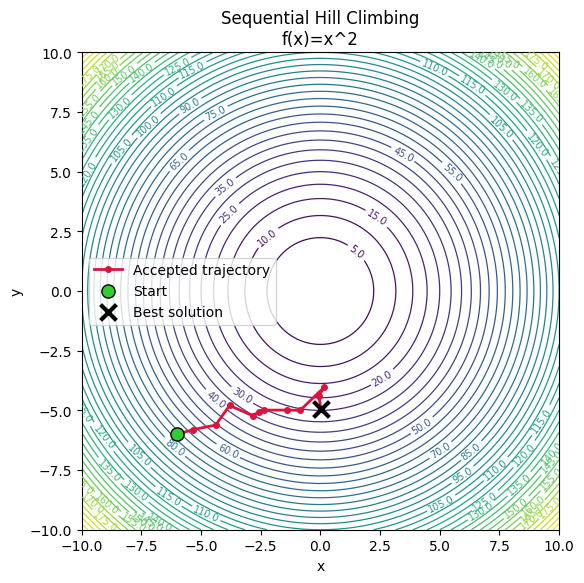

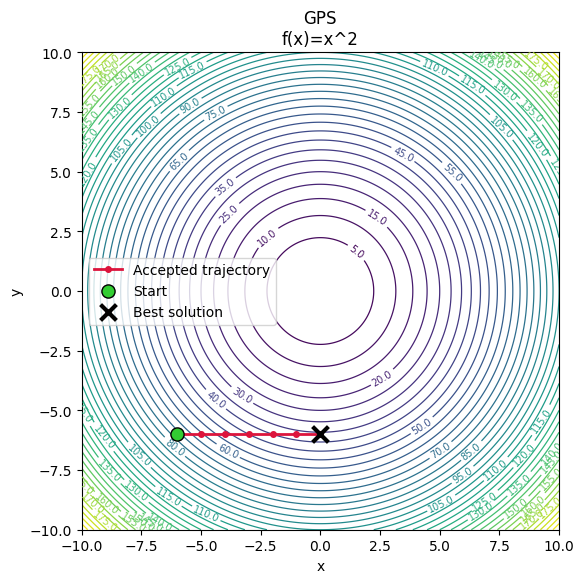

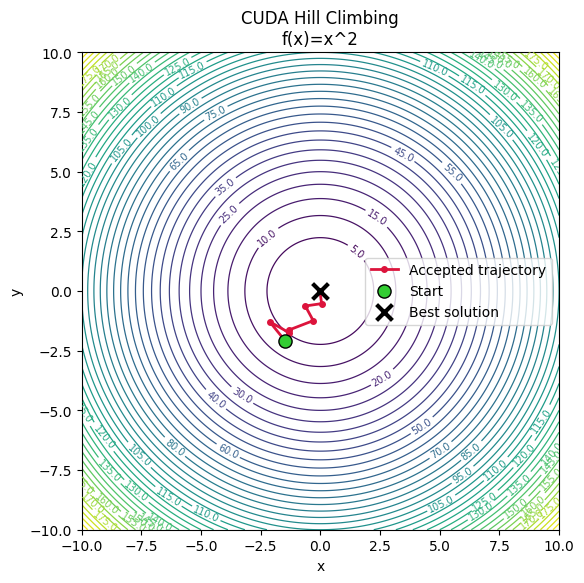

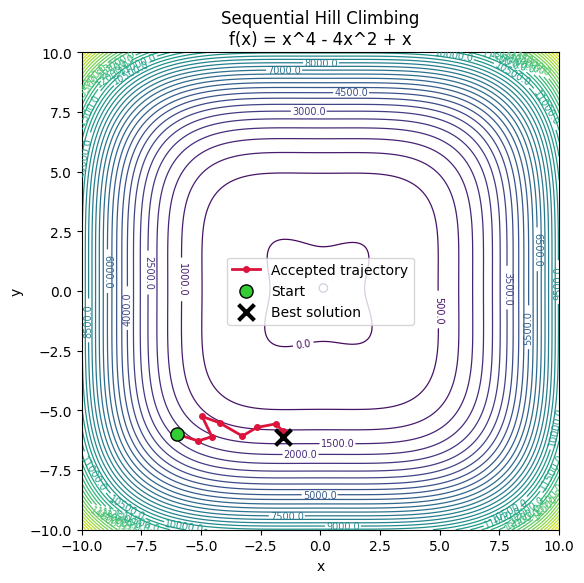

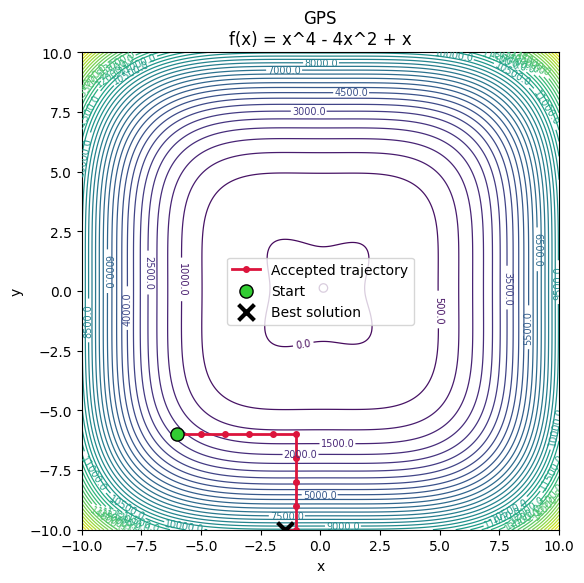

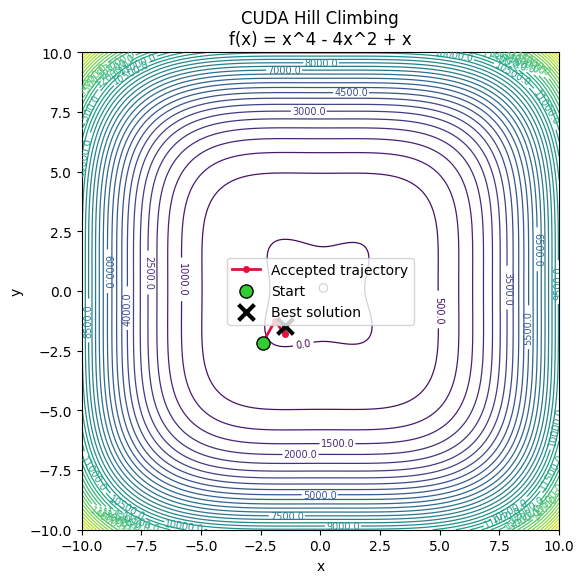

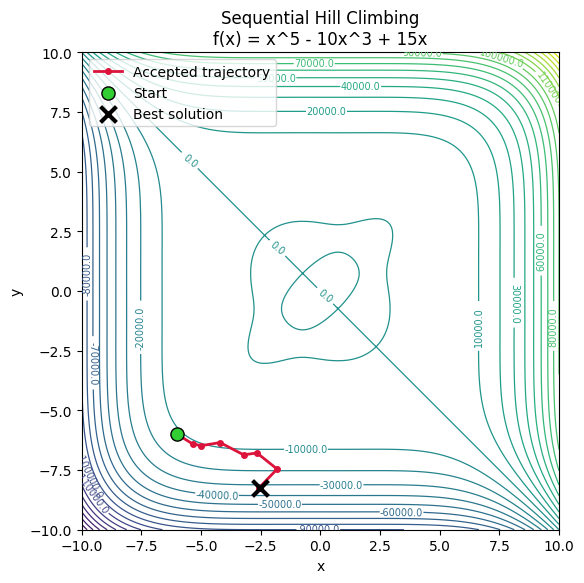

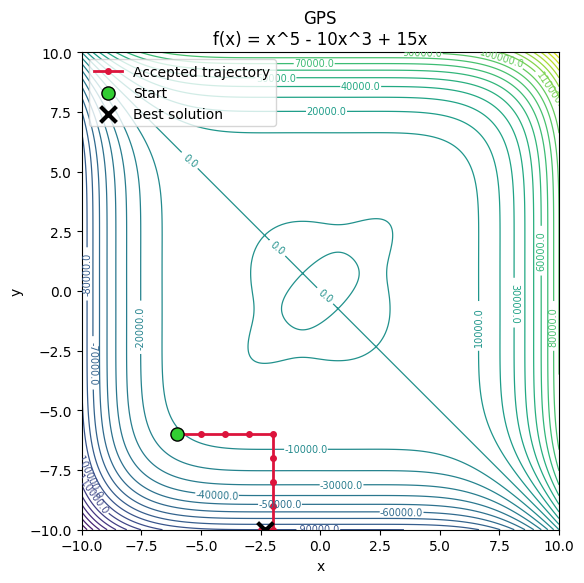

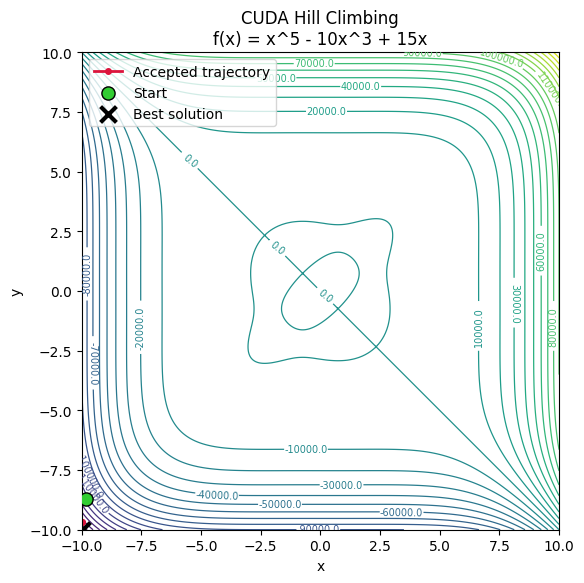

In [10]:
def plot_contour(function_id, function_name, algorithm_name, result, bounds=(-10.0, 10.0), levels=40):
    xs = np.linspace(bounds[0], bounds[1], 350)
    ys = np.linspace(bounds[0], bounds[1], 350)
    X, Y = np.meshgrid(xs, ys)
    Z = f_scalar(X, function_id) + f_scalar(Y, function_id)

    trajectory = result["trajectory"]

    fig, ax = plt.subplots(figsize=(7.5, 6.2))
    contour = ax.contour(X, Y, Z, levels=levels, cmap="viridis", linewidths=0.9)
    ax.clabel(contour, inline=True, fontsize=7, fmt="%.1f")

    ax.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        color="crimson",
        marker="o",
        markersize=4,
        linewidth=2,
        label="Accepted trajectory",
    )
    ax.scatter(trajectory[0, 0], trajectory[0, 1], color="limegreen", s=90, edgecolor="black", label="Start", zorder=4)
    ax.scatter(result["x_best"][0], result["x_best"][1], color="black", marker="x", s=130, linewidths=3, label="Best solution", zorder=5)

    ax.set_title(f"{algorithm_name}\n{function_name}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(bounds)
    ax.set_ylim(bounds)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best")
    plt.show()


for fn in FUNCTIONS:
    fid = fn["id"]
    for algorithm_name, result in results[fid].items():
        plot_contour(
            fid,
            fn["name"],
            algorithm_name,
            result,
            bounds=(PARAMS["search_min"], PARAMS["search_max"]),
        )